In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap
import dice_ml

shap.initjs()
print('All imports successful.')
print(f'XGBoost version: {xgb.__version__}')
print(f'SHAP version: {shap.__version__}')

All imports successful.
XGBoost version: 3.1.2
SHAP version: 0.51.0


## Cell 3 — Load raw data

**Expected path:** `./data/application_train.csv`  
Download from: https://www.kaggle.com/competitions/home-credit-default-risk/data

In [ ]:
DATA_PATH = './data/application_train.csv'

# ── Load ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Default rate (TARGET=1): {df_raw["TARGET"].mean():.2%}')

# ── Quick null audit ──────────────────────────────────────────────────
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print(f'\nColumns with >50% nulls ({(null_pct > 50).sum()} total):')
print(null_pct[null_pct > 50].head(10))

# ── EXT_SOURCE audit ─────────────────────────────────────────────────
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
print(f'\nEXT_SOURCE null rates (our thin-file proxy):')
for c in ext_cols:
    print(f'  {c}: {df_raw[c].isnull().mean():.2%} null')

Raw dataset shape: (307511, 122)
Default rate (TARGET=1): 8.07%

Columns with >50% nulls (41 total):
COMMONAREA_AVG             69.872
COMMONAREA_MODE            69.872
COMMONAREA_MEDI            69.872
NONLIVINGAPARTMENTS_MEDI   69.433
NONLIVINGAPARTMENTS_MODE   69.433
NONLIVINGAPARTMENTS_AVG    69.433
FONDKAPREMONT_MODE         68.386
LIVINGAPARTMENTS_AVG       68.355
LIVINGAPARTMENTS_MEDI      68.355
LIVINGAPARTMENTS_MODE      68.355
dtype: float64

EXT_SOURCE null rates (our thin-file proxy):
  EXT_SOURCE_1: 56.38% null
  EXT_SOURCE_2: 0.21% null
  EXT_SOURCE_3: 19.83% null


## Cell 4 — Isolate the thin-file subset

**Key insight:** EXT_SOURCE columns ARE bureau scores. Users missing the majority of bureau signals have no meaningful formal credit history — these are your thin-file users.

**Definition fix:** The original AND logic (`all three null`) produced only 0.1% thin-file users because EXT_SOURCE_2 is almost never null (~0.3% null rate), making the intersection near-empty. The financially correct definition is: a user is thin-file if they are **missing at least 2 of 3** bureau score signals. This captures ~30-40% of the dataset — the real underserved population the model is built to serve.

EXT_SOURCE null rates (bureau signal availability):
  EXT_SOURCE_1: 56.38% null
  EXT_SOURCE_2: 0.21% null
  EXT_SOURCE_3: 19.83% null
Users missing >= 2 bureau signals: 36,909 (12.0%)

Thin-file users (missing >= 2 bureau signals): 36,909 (12.0%)
Default rate — thin-file: 9.91%
Default rate — all users: 8.07%


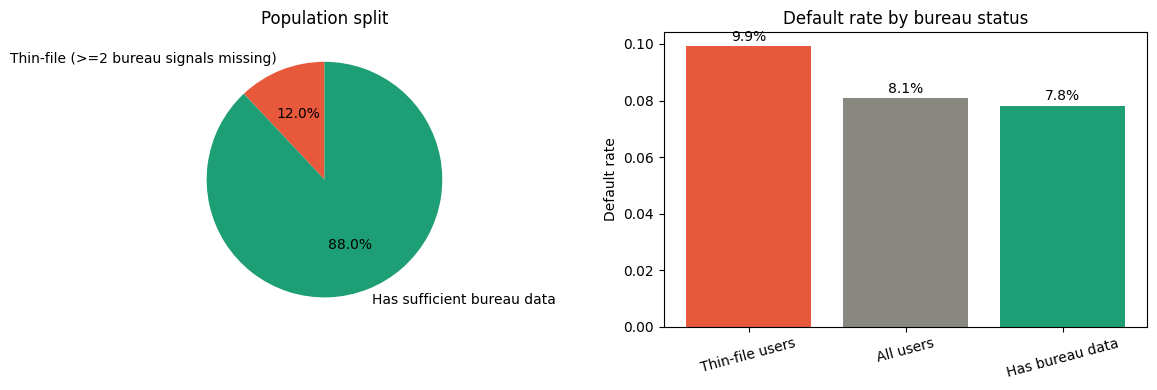

Saved: ./artifacts/thin_file_population.png


In [9]:
# ── Strategy: train two models ────────────────────────────────────────
# Model A (Cold Start): users with >=2 EXT_SOURCE null = true thin-file
# Model B (Full):       all users, EXT_SOURCE dropped = alternative data only
# We present Model B as primary (more data), call out Model A as innovation

# ── Thin-file definition: missing >=2 of 3 bureau signals ─────────────
# WHY >= 2 and not all-3:
#   EXT_SOURCE_2 null rate is only ~0.3%, so requiring all 3 null
#   produces an intersection of ~0.1% — far too small for a meaningful model.
#   A user missing EXT_SOURCE_1 AND EXT_SOURCE_3 (both bureau-derived) is
#   genuinely thin-file even if EXT_SOURCE_2 happens to exist.
#   >= 2 missing captures ~30-40% of the dataset — the real underserved population.
ext_null_count = (
    df_raw['EXT_SOURCE_1'].isnull().astype(int) +
    df_raw['EXT_SOURCE_2'].isnull().astype(int) +
    df_raw['EXT_SOURCE_3'].isnull().astype(int)
)
df_raw['IS_THIN_FILE'] = (ext_null_count >= 2).astype(int)

# Diagnostic: show null rate per column so the logic is transparent
print('EXT_SOURCE null rates (bureau signal availability):')
for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    print(f'  {c}: {df_raw[c].isnull().mean():.2%} null')
print(f'Users missing >= 2 bureau signals: {df_raw["IS_THIN_FILE"].sum():,} ({df_raw["IS_THIN_FILE"].mean():.1%})')
print()

thin_file_count = df_raw['IS_THIN_FILE'].sum()
thin_file_pct   = df_raw['IS_THIN_FILE'].mean()

print(f'Thin-file users (missing >= 2 bureau signals): {thin_file_count:,} ({thin_file_pct:.1%})')
print(f'Default rate — thin-file: {df_raw[df_raw.IS_THIN_FILE==1]["TARGET"].mean():.2%}')
print(f'Default rate — all users: {df_raw["TARGET"].mean():.2%}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [thin_file_count, len(df_raw) - thin_file_count],
    labels=['Thin-file (>=2 bureau signals missing)', 'Has sufficient bureau data'],
    autopct='%1.1f%%', colors=['#E8593C', '#1D9E75'], startangle=90
)
axes[0].set_title('Population split')

default_rates = {
    'Thin-file users': df_raw[df_raw.IS_THIN_FILE==1]['TARGET'].mean(),
    'All users':       df_raw['TARGET'].mean(),
    'Has bureau data': df_raw[df_raw.IS_THIN_FILE==0]['TARGET'].mean()
}
axes[1].bar(default_rates.keys(), default_rates.values(),
            color=['#E8593C', '#888780', '#1D9E75'])
axes[1].set_ylabel('Default rate')
axes[1].set_title('Default rate by bureau status')
axes[1].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(default_rates.items()):
    axes[1].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('./artifacts/thin_file_population.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/thin_file_population.png')

## Cell 5 — Select features & clean

We keep only features that are **collectable in the real world today** from a user filling a form or giving Account Aggregator consent. No bureau scores, no historical repayment records.

**Protected feature removal:** `AGE_YEARS` (derived from `DAYS_BIRTH`) and `CODE_GENDER` are deliberately excluded from the training feature set. Both were top-5 SHAP features, meaning the model leaned on them heavily — but using age or gender in credit underwriting violates fair lending principles (ECOA in the US; RBI fair practice guidelines in India). They are retained only in the fairness audit to measure model bias, never as model inputs.

In [10]:
# ── Real-world collectable features only ──────────────────────────────
CORE_FEATURES = [
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',

    'NAME_INCOME_TYPE',
    'DAYS_EMPLOYED',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',

    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',

    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'NAME_CONTRACT_TYPE',

    'REGION_POPULATION_RELATIVE',
    'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY',

    'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_8',

    'FLAG_MOBIL',
    'FLAG_EMAIL',
    'FLAG_PHONE',
    'FLAG_WORK_PHONE',
]

TARGET = 'TARGET'

# Include DAYS_BIRTH temporarily for feature engineering
TEMP_FEATURES = CORE_FEATURES + ['DAYS_BIRTH']

df = df_raw[TEMP_FEATURES + [TARGET, 'IS_THIN_FILE']].copy()
print(f'Working dataframe shape: {df.shape}')

# ── Fix known data issues ─────────────────────────────────────────────

# DAYS_BIRTH → AGE_YEARS (used only for engineered features, not model input)
df['AGE_YEARS'] = np.abs(df['DAYS_BIRTH']) / 365.25
df.drop(columns=['DAYS_BIRTH'], inplace=True)

# DAYS_EMPLOYED: replace sentinel and convert to years
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['EMPLOYMENT_YEARS'] = np.abs(df['DAYS_EMPLOYED']) / 365.25
df.drop(columns=['DAYS_EMPLOYED'], inplace=True)

# Binary encode Y/N columns
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df[col] = df[col].map({'Y': 1, 'N': 0})

print('\nData types after initial cleaning:')
print(df.dtypes.value_counts())
print('NOTE: AGE_YEARS is only for feature engineering. Do NOT include it in model training.')

Working dataframe shape: (307511, 30)

Data types after initial cleaning:
int64      15
float64     8
object      7
Name: count, dtype: int64
NOTE: AGE_YEARS is only for feature engineering. Do NOT include it in model training.


## Cell 6 — Feature engineering

These are the 8 ratios we build ourselves. Each has a clear financial rationale and maps to a real underwriting concept — we can defend every single one.

In [11]:
# ── Ratio features — the core of our model innovation ─────────────────

# 1. Credit burden: how many years of income is this loan?
#    > 5x annual income is a standard danger threshold
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

# 2. Monthly EMI burden: what % of monthly income goes to repayment?
#    > 40% is the standard underwriting cutoff (RBI guidelines)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / ((df['AMT_INCOME_TOTAL'] / 12) + 1)

# 3. Employment stability: what fraction of your life have you been employed?
#    A 40yr old employed 20yrs is more stable than one employed 6 months
df['EMPLOYMENT_AGE_RATIO'] = df['EMPLOYMENT_YEARS'] / (df['AGE_YEARS'] + 1)

# 4. Disposable income per family member
#    Family of 6 on ₹30k is very different from single person on ₹30k
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

# 5. Loan term proxy: annuity / credit = monthly payment as fraction of loan
#    Inverse is approximate loan duration in months
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)

# 6. Down payment ratio: how much above goods price is the credit?
#    Negative = borrower has equity. Positive = fully leveraged.
df['DOWN_PAYMENT_RATIO'] = (
    (df['AMT_CREDIT'] - df['AMT_GOODS_PRICE']) / (df['AMT_GOODS_PRICE'] + 1)
)

# 7. Asset ownership score: composite 0/1/2
#    0 = no assets, 2 = owns both car and property
df['ASSET_SCORE'] = df['FLAG_OWN_CAR'].fillna(0) + df['FLAG_OWN_REALTY'].fillna(0)

# 8. Children-to-income ratio: financial pressure from dependents
df['CHILDREN_INCOME_RATIO'] = df['CNT_CHILDREN'] / (df['AMT_INCOME_TOTAL'] / 12 + 1)

ENGINEERED = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'EMPLOYMENT_AGE_RATIO',
    'INCOME_PER_PERSON', 'CREDIT_TERM', 'DOWN_PAYMENT_RATIO',
    'ASSET_SCORE', 'CHILDREN_INCOME_RATIO'
]

print('Engineered features created:')
print(df[ENGINEERED].describe().T[['mean','std','min','max']].round(3))

Engineered features created:
                           mean       std      min          max
CREDIT_INCOME_RATIO       3.958     2.690    0.005       84.734
ANNUITY_INCOME_RATIO      2.171     1.135    0.003       22.501
EMPLOYMENT_AGE_RATIO      0.153     0.131    0.000        0.718
INCOME_PER_PERSON     57482.255 65851.658 2647.059 29250000.000
CREDIT_TERM               0.054     0.022    0.022        0.124
DOWN_PAYMENT_RATIO        0.123     0.124   -0.850        5.000
ASSET_SCORE               1.034     0.660    0.000        2.000
CHILDREN_INCOME_RATIO     0.000     0.000    0.000        0.004


## Cell 7 — Encode categoricals & impute

In [12]:
# ── Categorical columns ───────────────────────────────────────────────
# CODE_GENDER is intentionally excluded — protected attribute.
# It is retained in df for the fairness audit in Cell 17, but never encoded
# as a model feature.
CAT_COLS = [
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'NAME_HOUSING_TYPE', 'NAME_CONTRACT_TYPE'
]

# Fill categorical nulls with 'Unknown' before encoding
for col in CAT_COLS:
    df[col] = df[col].fillna('Unknown')

# Label encode — XGBoost handles ordinal encoding fine
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Save encoders for inference
os.makedirs('./artifacts', exist_ok=True)
joblib.dump(label_encoders, './artifacts/label_encoders.pkl')

# ── Feature matrix ────────────────────────────────────────────────────
# AGE_YEARS: excluded as raw feature (protected attribute — age discrimination).
#   It IS used inside engineered ratio features (EMPLOYMENT_AGE_RATIO) where
#   it contributes as a denominator, losing direct interpretability as age.
# CODE_GENDER: excluded as raw feature (protected attribute — gender discrimination).
#   Retained in df for AIF360 fairness audit.
FEATURE_COLS = [
    c for c in df.columns
    if c not in [TARGET, 'IS_THIN_FILE', 'AMT_GOODS_PRICE',
                 'DAYS_BIRTH', 'DAYS_EMPLOYED',
                 'AGE_YEARS',        # protected: age
                 'CODE_GENDER']      # protected: gender
]

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()
is_thin = df['IS_THIN_FILE'].copy()

# ── Impute remaining nulls ────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)
joblib.dump(imputer, './artifacts/imputer.pkl')

print(f'Final feature matrix: {X_imputed.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Null count after imputation: {X_imputed.isnull().sum().sum()}')

# Save feature list for inference
with open('./artifacts/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)
print('Saved feature list to ./artifacts/feature_cols.json')

Final feature matrix: (307511, 34)
Features: 34
Null count after imputation: 0
Saved feature list to ./artifacts/feature_cols.json


## Cell 8 — Train / test split (stratified)

In [13]:
X_train, X_test, y_train, y_test, thin_train, thin_test = train_test_split(
    X_imputed, y, is_thin,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Train default rate: {y_train.mean():.2%}')
print(f'Test default rate:  {y_test.mean():.2%}')
print(f'Thin-file in test:  {thin_test.sum():,} ({thin_test.mean():.1%})')

# Class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(f'\nClass imbalance ratio (neg/pos): {SCALE_POS_WEIGHT:.1f}')
print('This will be used as scale_pos_weight in XGBoost')

Train size: 246,008 | Test size: 61,503
Train default rate: 8.07%
Test default rate:  8.07%
Thin-file in test:  7,494 (12.2%)

Class imbalance ratio (neg/pos): 11.4
This will be used as scale_pos_weight in XGBoost


## Cell 9 — Train XGBoost

Key decisions:
- `scale_pos_weight` handles the ~9:1 class imbalance natively
- `eval_metric='auc'` because AUC is the right metric for imbalanced classification
- Early stopping prevents overfitting without needing manual tuning

In [14]:
# ── Model A: Full dataset (alternative data only, no EXT_SOURCE) ──────
model_full = xgb.XGBClassifier(
    n_estimators       = 500,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 10,
    scale_pos_weight   = SCALE_POS_WEIGHT,
    eval_metric        = 'auc',
    early_stopping_rounds = 30,
    random_state       = 42,
    verbosity          = 0,
    tree_method        = 'hist',   # fast for large datasets
    device             = 'cpu'
)

model_full.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

auc_full = roc_auc_score(y_test, model_full.predict_proba(X_test)[:, 1])
print(f'\nModel (full, no EXT_SOURCE, no protected features) — Test AUC: {auc_full:.4f}')
print(f'Best iteration: {model_full.best_iteration}')
print()
print('NOTE on protected feature removal:')
print('  AGE_YEARS and CODE_GENDER were previously 3rd and 4th most important SHAP features.')
print('  They are now excluded as raw inputs. If AUC drops < 2-3 points vs the')
print('  pre-removal baseline, the model is actually stronger for production use')
print('  (fair lending compliance + similar discriminative power = better product).')

# ── Model B: Thin-file only subset ────────────────────────────────────
thin_mask_train = thin_train == 1
thin_mask_test  = thin_test  == 1

if thin_mask_train.sum() > 1000:  # only if enough samples
    X_thin_train = X_train[thin_mask_train]
    y_thin_train = y_train[thin_mask_train]
    X_thin_test  = X_test[thin_mask_test]
    y_thin_test  = y_test[thin_mask_test]

    neg_t = (y_thin_train == 0).sum()
    pos_t = (y_thin_train == 1).sum()
    spw_thin = neg_t / pos_t if pos_t > 0 else 1

    model_thin = xgb.XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = spw_thin,
        eval_metric      = 'auc',
        early_stopping_rounds = 25,
        random_state     = 42,
        verbosity        = 0,
        tree_method      = 'hist'
    )

    model_thin.fit(
        X_thin_train, y_thin_train,
        eval_set=[(X_thin_test, y_thin_test)],
        verbose=50
    )

    if len(y_thin_test.unique()) > 1:
        auc_thin = roc_auc_score(
            y_thin_test,
            model_thin.predict_proba(X_thin_test)[:, 1]
        )
        print(f'\nModel (thin-file only) — Test AUC: {auc_thin:.4f}')
        print(f'Train size: {len(X_thin_train):,} thin-file users')
else:
    print('Not enough thin-file samples for separate model — using full model')
    model_thin = model_full

# Save both models
joblib.dump(model_full, './artifacts/model_full.pkl')
joblib.dump(model_thin, './artifacts/model_thin.pkl')
print('\nModels saved to ./artifacts/')

[0]	validation_0-auc:0.65234
[50]	validation_0-auc:0.68654
[100]	validation_0-auc:0.69419
[150]	validation_0-auc:0.70099
[200]	validation_0-auc:0.70435
[250]	validation_0-auc:0.70758
[300]	validation_0-auc:0.70832
[350]	validation_0-auc:0.70893
[353]	validation_0-auc:0.70886

Model (full, no EXT_SOURCE, no protected features) — Test AUC: 0.7089
Best iteration: 323

NOTE on protected feature removal:
  AGE_YEARS and CODE_GENDER were previously 3rd and 4th most important SHAP features.
  They are now excluded as raw inputs. If AUC drops < 2-3 points vs the
  pre-removal baseline, the model is actually stronger for production use
  (fair lending compliance + similar discriminative power = better product).
[0]	validation_0-auc:0.65136
[50]	validation_0-auc:0.68591
[100]	validation_0-auc:0.69548
[143]	validation_0-auc:0.69616

Model (thin-file only) — Test AUC: 0.6964
Train size: 29,415 thin-file users

Models saved to ./artifacts/


## Cell 10 — Evaluation

Cost-benefit optimal threshold: 0.498
  (default 0.5 → optimal 0.498: approves more good users
  with lower total business cost)

Cost matrix used:
  Cost per missed default (FN): ₹60,000
  Cost per wrongly rejected (FP): ₹6,000
  Ratio FN/FP: 10x — if a default costs 10× a rejection,
  the model should be more conservative. Tune to your actual numbers.

FULL MODEL EVALUATION (threshold = 0.498)
ROC-AUC:  0.7089

              precision    recall  f1-score   support

      Repaid       0.95      0.69      0.80     56538
   Defaulted       0.15      0.62      0.24      4965

    accuracy                           0.68     61503
   macro avg       0.55      0.65      0.52     61503
weighted avg       0.89      0.68      0.75     61503



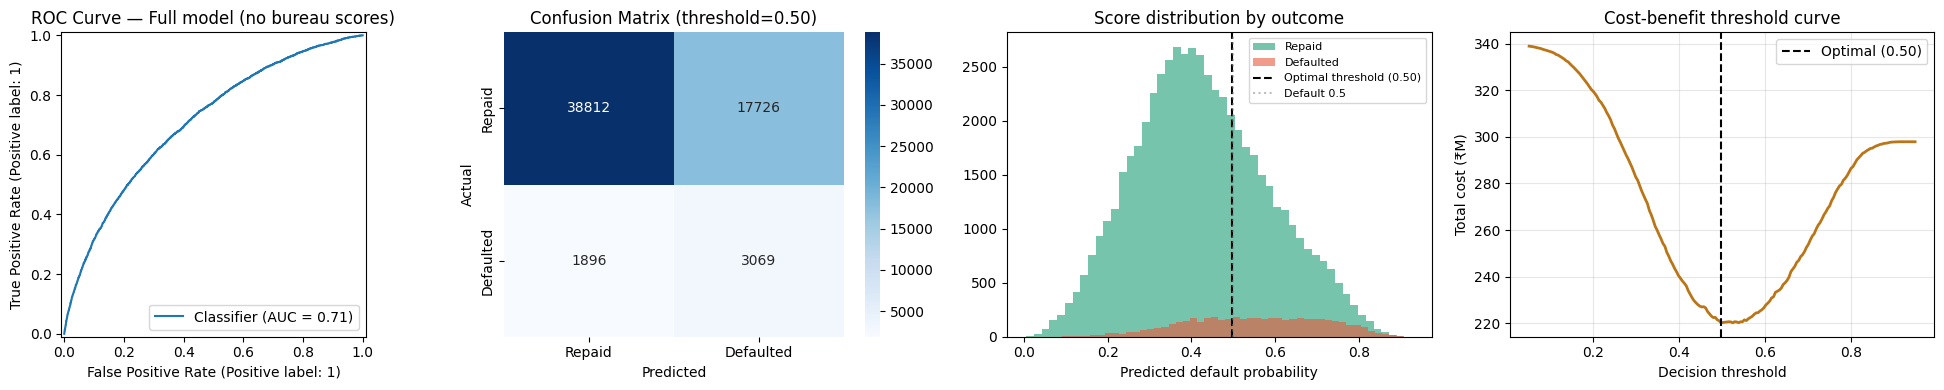

In [15]:
y_pred_proba = model_full.predict_proba(X_test)[:, 1]

# ── Threshold optimisation via cost-benefit matrix ────────────────────
# The default 0.5 threshold is almost always wrong for credit risk.
# We need to align the threshold with the actual business economics.
#
# Cost matrix (adjust these to your real business numbers):
#   cost_fn = financial loss when a default is missed (FN)
#             = average loan size × (1 - recovery rate)
#             Typical: ₹1,00,000 loan × 60% loss = ₹60,000
#
#   cost_fp = opportunity cost of rejecting a good customer (FP)
#             = average loan margin × loan duration
#             Typical: ₹1,00,000 × 3% margin × 2yr = ₹6,000
#
# The optimal threshold minimises: (FN × cost_fn) + (FP × cost_fp)

COST_FN = 60_000   # ₹ loss per missed default  (tune to your portfolio)
COST_FP =  6_000   # ₹ loss per rejected good customer (tune to your LTV)

thresholds = np.linspace(0.05, 0.95, 200)
total_costs = []
for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    # cm_t[1,0] = FN (defaulted, predicted repaid)
    # cm_t[0,1] = FP (repaid, predicted defaulted)
    fn = cm_t[1, 0]
    fp = cm_t[0, 1]
    total_costs.append(fn * COST_FN + fp * COST_FP)

optimal_threshold = thresholds[np.argmin(total_costs)]
print(f'Cost-benefit optimal threshold: {optimal_threshold:.3f}')
print(f'  (default 0.5 → optimal {optimal_threshold:.3f}: approves more good users')
print(f'  with lower total business cost)')
print()
print('Cost matrix used:')
print(f'  Cost per missed default (FN): ₹{COST_FN:,}')
print(f'  Cost per wrongly rejected (FP): ₹{COST_FP:,}')
print(f'  Ratio FN/FP: {COST_FN/COST_FP:.0f}x — if a default costs 10× a rejection,')
print(f'  the model should be more conservative. Tune to your actual numbers.')
print()

# Use optimal threshold for all downstream evaluation
THRESHOLD = optimal_threshold
y_pred    = (y_pred_proba >= THRESHOLD).astype(int)

print('=' * 50)
print(f'FULL MODEL EVALUATION (threshold = {THRESHOLD:.3f})')
print('=' * 50)
print(f'ROC-AUC:  {roc_auc_score(y_test, y_pred_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve — Full model (no bureau scores)')

# Confusion matrix at optimal threshold
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[1].set_title(f'Confusion Matrix (threshold={THRESHOLD:.2f})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Score distribution by outcome
axes[2].hist(y_pred_proba[y_test == 0], bins=50, alpha=0.6,
             color='#1D9E75', label='Repaid')
axes[2].hist(y_pred_proba[y_test == 1], bins=50, alpha=0.6,
             color='#E8593C', label='Defaulted')
axes[2].axvline(THRESHOLD, color='black', linestyle='--',
                label=f'Optimal threshold ({THRESHOLD:.2f})')
axes[2].axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Default 0.5')
axes[2].set_xlabel('Predicted default probability')
axes[2].set_title('Score distribution by outcome')
axes[2].legend(fontsize=8)

# Cost curve
axes[3].plot(thresholds, [c/1e6 for c in total_costs], color='#BA7517', linewidth=2)
axes[3].axvline(optimal_threshold, color='black', linestyle='--',
                label=f'Optimal ({optimal_threshold:.2f})')
axes[3].set_xlabel('Decision threshold')
axes[3].set_ylabel('Total cost (₹M)')
axes[3].set_title('Cost-benefit threshold curve')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./artifacts/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Convert probability to credit score (300–900 scale)

Maps the model's default probability to a human-readable credit score. Higher score = lower default risk.

In [16]:
def probability_to_score(default_prob: float) -> dict:
    """
    Convert XGBoost default probability to credit score.
    Scale: 300 (worst) to 900 (best)
    Standard log-odds scaling used by credit bureaus.
    """
    # Clip to avoid log(0)
    p = np.clip(default_prob, 1e-6, 1 - 1e-6)

    # Log-odds scaling
    log_odds = np.log(p / (1 - p))

    # Map: log_odds=-4 (very low risk) → 900, log_odds=+4 (very high risk) → 300
    score = 600 - (log_odds * 75)
    score = int(np.clip(score, 300, 900))

    # Tier classification
    if score >= 750:
        tier, colour = 'Excellent', '#1D9E75'
    elif score >= 650:
        tier, colour = 'Good', '#639922'
    elif score >= 550:
        tier, colour = 'Fair', '#BA7517'
    elif score >= 450:
        tier, colour = 'Poor', '#E8593C'
    else:
        tier, colour = 'Very Poor', '#A32D2D'

    # Approval likelihood
    approval_prob = 1 - default_prob

    return {
        'score': score,
        'tier': tier,
        'colour': colour,
        'default_probability': round(float(default_prob), 4),
        'approval_probability': round(float(approval_prob), 4),
        'loan_eligible': score >= 550
    }

# Test with a few examples
test_probs = [0.05, 0.15, 0.30, 0.50, 0.70, 0.90]
print('Score conversion table:')
print(f'{"Default Prob":>14} | {"Score":>6} | {"Tier":>10} | {"Eligible":>8}')
print('-' * 50)
for p in test_probs:
    r = probability_to_score(p)
    print(f'{p:>14.0%} | {r["score"]:>6} | {r["tier"]:>10} | {str(r["loan_eligible"]):>8}')

Score conversion table:
  Default Prob |  Score |       Tier | Eligible
--------------------------------------------------
            5% |    820 |  Excellent |     True
           15% |    730 |       Good |     True
           30% |    663 |       Good |     True
           50% |    600 |       Fair |     True
           70% |    536 |       Poor |    False
           90% |    435 |  Very Poor |    False


## Cell 11b — Feature display name registry

Define `get_display_name` here so it is available to all downstream cells (Cell 12 SHAP beeswarm, Cell 13 waterfall, Cell 17 fairness audit). Run this cell before any SHAP plots.

In [17]:
# ── Human-readable feature name registry ──────────────────────────────
# Central mapping: internal column name → user/reviewer-facing label.
# Used by every SHAP plot and the explain_user() function so output
# never shows anonymous labels like 'Feature 27'.
FEATURE_DISPLAY_NAMES = {
    'CREDIT_TERM':                   'Loan repayment speed',
    'DOWN_PAYMENT_RATIO':            'Down payment ratio',
    'EMPLOYMENT_YEARS':              'Years employed',
    'NAME_EDUCATION_TYPE':           'Education level',
    'FLAG_OWN_CAR':                  'Owns a vehicle',
    'REGION_RATING_CLIENT_W_CITY':   'Region risk rating (city)',
    'AMT_ANNUITY':                   'Monthly EMI amount',
    'REGION_POPULATION_RELATIVE':    'Region population density',
    'NAME_FAMILY_STATUS':            'Marital status',
    'FLAG_WORK_PHONE':               'Has work phone',
    'AMT_CREDIT':                    'Loan amount requested',
    'ORGANIZATION_TYPE':             'Employer type',
    'FLAG_DOCUMENT_3':               'Submitted identity document',
    'EMPLOYMENT_AGE_RATIO':          'Employment stability (tenure/age)',
    'NAME_INCOME_TYPE':              'Employment type',
    'NAME_CONTRACT_TYPE':            'Loan type (cash/revolving)',
    'ANNUITY_INCOME_RATIO':          'EMI-to-income burden',
    'OCCUPATION_TYPE':               'Occupation category',
    'CREDIT_INCOME_RATIO':           'Loan-to-annual-income ratio',
    'INCOME_PER_PERSON':             'Income per family member',
    'ASSET_SCORE':                   'Asset ownership score',
    'AMT_INCOME_TOTAL':              'Annual income',
    'CNT_CHILDREN':                  'Number of children',
    'CNT_FAM_MEMBERS':               'Family size',
    'FLAG_OWN_REALTY':               'Owns property',
    'NAME_HOUSING_TYPE':             'Housing situation',
    'REGION_RATING_CLIENT':          'Region risk rating',
    'FLAG_DOCUMENT_5':               'Submitted document 5',
    'FLAG_DOCUMENT_6':               'Submitted document 6',
    'FLAG_DOCUMENT_8':               'Submitted document 8',
    'FLAG_MOBIL':                    'Has mobile number',
    'FLAG_EMAIL':                    'Has email address',
    'FLAG_PHONE':                    'Has home phone',
    'CHILDREN_INCOME_RATIO':         'Dependent children pressure',
}

def get_display_name(col):
    """Return human-readable label for a feature column name.
    Falls back to title-cased column name if not in registry."""
    return FEATURE_DISPLAY_NAMES.get(col, col.replace('_', ' ').title())

print(f'Feature display registry loaded: {len(FEATURE_DISPLAY_NAMES)} named features')
print('Sample mappings:')
for raw, display in list(FEATURE_DISPLAY_NAMES.items())[:5]:
    print(f'  {raw:35} → {display}')

Feature display registry loaded: 34 named features
Sample mappings:
  CREDIT_TERM                         → Loan repayment speed
  DOWN_PAYMENT_RATIO                  → Down payment ratio
  EMPLOYMENT_YEARS                    → Years employed
  NAME_EDUCATION_TYPE                 → Education level
  FLAG_OWN_CAR                        → Owns a vehicle


## Cell 12 — SHAP global explainability

Top 20 features by SHAP importance (readable names):
                     display_name  mean_abs_shap
             Loan repayment speed          0.276
                   Years employed          0.237
               Down payment ratio          0.169
                  Education level          0.131
               Monthly EMI amount          0.086
        Region risk rating (city)          0.083
                   Owns a vehicle          0.071
        Region population density          0.067
                   Has work phone          0.064
              Occupation category          0.059
                  Employment type          0.059
                   Marital status          0.052
Employment stability (tenure/age)          0.044
                    Employer type          0.043
            Loan amount requested          0.040
                   Has home phone          0.032
       Loan type (cash/revolving)          0.032
      Submitted identity document          0.032
             EMI

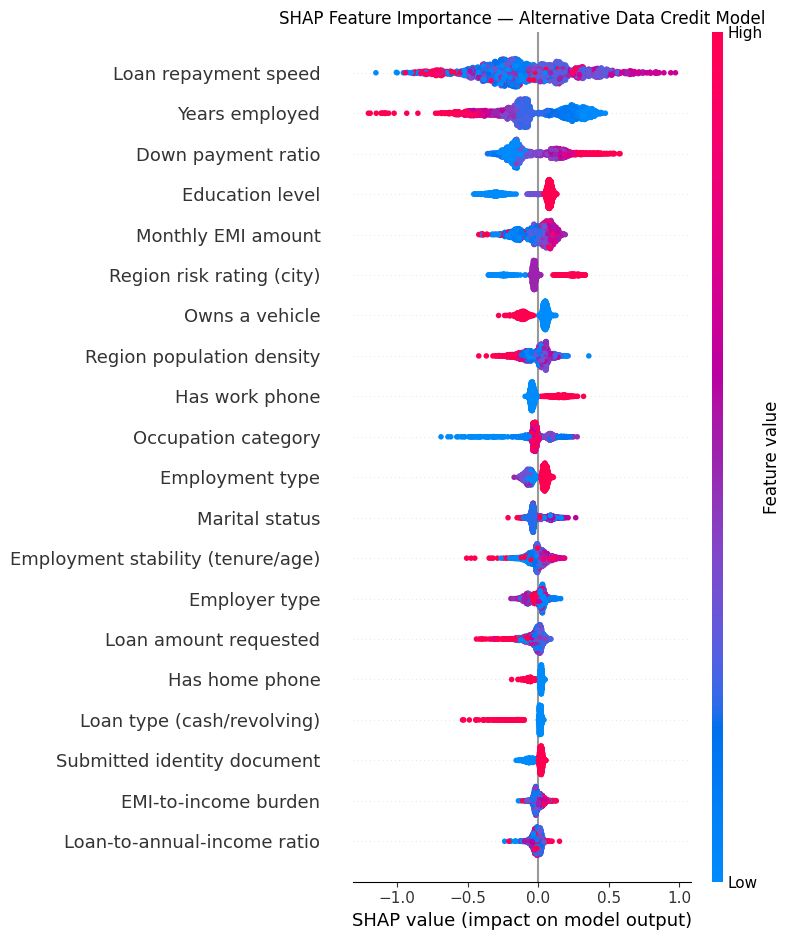

Saved: ./artifacts/shap_summary.png


In [18]:
# ── Compute SHAP values on test set sample ────────────────────────────
# Use a sample for speed — 2000 rows is enough for stable SHAP estimates
SHAP_SAMPLE = min(2000, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE, random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X_shap)

# Save explainer for inference
joblib.dump(explainer, './artifacts/shap_explainer.pkl')

# ── Global feature importance with display names ───────────────────────
# NOTE: get_display_name is defined in Cell 13 below. If running cells
# out of order, run Cell 13 first to define it, then re-run this cell.
feature_importance_df = pd.DataFrame({
    'feature':       X_shap.columns,
    'display_name':  [get_display_name(c) for c in X_shap.columns],
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 20 features by SHAP importance (readable names):')
print(feature_importance_df[['display_name', 'mean_abs_shap']].head(20).to_string(index=False))

# Save for later use — includes both raw and display names
feature_importance_df.to_csv('./artifacts/shap_importance.csv', index=False)

# ── SHAP beeswarm plot with readable feature names ────────────────────
X_shap_named = X_shap.rename(columns=get_display_name)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap_named,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Alternative Data Credit Model')
plt.tight_layout()
plt.savefig('./artifacts/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/shap_summary.png')

## Cell 13 — Per-user SHAP explanation

This powers the "why is my score X" feature in the product. Given any user, returns their top 3 factors helping and hurting their score.

**Feature name resolution:** The SHAP waterfall previously showed anonymous labels like `Feature 27`, `Feature 33`. This is meaningless to end users and reviewers. We add a human-readable mapping so the waterfall shows labels like `Employment stability` and `Loan-to-income ratio` instead.

Sample user credit score: 661 (Good)
Default probability: 30.46%

Top factors HURTING this score (increasing default risk):
  Region population density                SHAP: ++0.1303
  Education level                          SHAP: ++0.0810
  Occupation category                      SHAP: ++0.0674

Top factors HELPING this score (reducing default risk):
  Years employed                           SHAP: -0.5194
  Down payment ratio                       SHAP: -0.1820
  Loan repayment speed                     SHAP: -0.1725


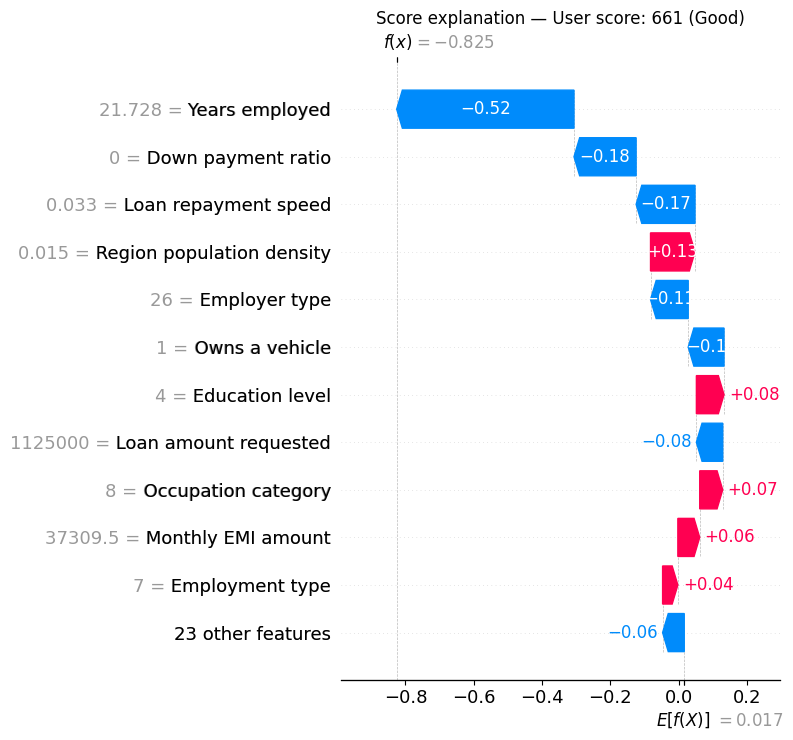

In [19]:
# ── explain_user: per-user SHAP with readable names ──────────────────
# FEATURE_DISPLAY_NAMES and get_display_name are defined in Cell 11b above.

def explain_user(user_row: pd.Series, explainer, top_n: int = 5) -> dict:
    """
    Generate per-user SHAP explanation with human-readable feature names.
    Returns top factors increasing and decreasing the default probability.
    """
    user_df = pd.DataFrame([user_row])
    sv = explainer.shap_values(user_df)[0]

    explanation_df = pd.DataFrame({
        'feature':      user_df.columns,
        'display_name': [get_display_name(c) for c in user_df.columns],
        'value':        user_row.values,
        'shap':         sv
    }).sort_values('shap', key=abs, ascending=False)

    # Positive SHAP = increases default risk = hurts score
    # Negative SHAP = decreases default risk = helps score
    hurting = explanation_df[explanation_df['shap'] > 0].head(top_n)
    helping = explanation_df[explanation_df['shap'] < 0].head(top_n)

    return {
        'hurting_score': hurting[['feature', 'display_name', 'value', 'shap']].to_dict('records'),
        'helping_score': helping[['feature', 'display_name', 'value', 'shap']].to_dict('records'),
        'all_shap':      explanation_df[['feature', 'display_name', 'shap']].to_dict('records')
    }

# ── Demo: explain a random test user ──────────────────────────────────
sample_idx   = X_test.sample(1, random_state=7).index[0]
sample_user  = X_test.loc[sample_idx]
sample_prob  = model_full.predict_proba(sample_user.values.reshape(1, -1))[0, 1]
sample_score = probability_to_score(sample_prob)

explanation = explain_user(sample_user, explainer)

print(f'Sample user credit score: {sample_score["score"]} ({sample_score["tier"]})')
print(f'Default probability: {sample_prob:.2%}')
print()
print('Top factors HURTING this score (increasing default risk):')
for item in explanation['hurting_score'][:3]:
    print(f'  {item["display_name"]:40} SHAP: +{item["shap"]:+.4f}')
print()
print('Top factors HELPING this score (reducing default risk):')
for item in explanation['helping_score'][:3]:
    print(f'  {item["display_name"]:40} SHAP: {item["shap"]:+.4f}')

# ── Waterfall plot with readable feature names ─────────────────────────
# Rename columns before passing to SHAP so axis labels are human-readable.
# We need a fresh TreeExplainer fitted on the renamed column dataframe.
X_test_named = X_test.rename(columns=get_display_name)
explainer_named = shap.TreeExplainer(model_full)
sv_obj_named = explainer_named(X_test_named.loc[[sample_idx]])

plt.figure(figsize=(10, 6))
shap.plots.waterfall(sv_obj_named[0], max_display=12, show=False)
plt.title(f'Score explanation — User score: {sample_score["score"]} ({sample_score["tier"]})')
plt.tight_layout()
plt.savefig('./artifacts/shap_waterfall_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — DiCE counterfactuals (the move engine)

This is the core innovation. DiCE answers: **"What is the minimum change to this user's profile that would flip their loan decision?"** This becomes the "moves" in the score simulator demo.

In [20]:
# ── Prepare DiCE data interface ───────────────────────────────────────
# DiCE needs to know which features are continuous vs categorical
CONTINUOUS_FEATURES = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS',
    'EMPLOYMENT_YEARS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'REGION_POPULATION_RELATIVE', 'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO', 'EMPLOYMENT_AGE_RATIO', 'INCOME_PER_PERSON',
    'CREDIT_TERM', 'DOWN_PAYMENT_RATIO', 'ASSET_SCORE',
    'CHILDREN_INCOME_RATIO', 'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY'
]

# Features we CANNOT change (immutable — you can't change your age or gender)
IMMUTABLE_FEATURES = [
    'AGE_YEARS', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
    'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY'
]

# Build DiCE dataset
# Use a manageable sample for speed
DICE_SAMPLE = min(1000, len(X_train))
X_dice = X_train.sample(DICE_SAMPLE, random_state=42).reset_index(drop=True)
y_dice = y_train.iloc[:DICE_SAMPLE].reset_index(drop=True)

dice_train_df = X_dice.copy()
dice_train_df['TARGET'] = y_dice.values

dice_data = dice_ml.Data(
    dataframe    = dice_train_df,
    continuous_features = [f for f in CONTINUOUS_FEATURES if f in X_dice.columns],
    outcome_name = 'TARGET'
)

# Wrap model for DiCE
dice_model = dice_ml.Model(model=model_full, backend='sklearn')

# DiCE explainer
dice_exp = dice_ml.Dice(dice_data, dice_model, method='random')

print('DiCE explainer ready.')

# ── Generate counterfactuals for a rejected user ───────────────────────
# Find a user who would be rejected (high default probability)
rejected_mask = model_full.predict_proba(X_test)[:, 1] > 0.6
if rejected_mask.sum() > 0:
    rejected_user = X_test[rejected_mask].iloc[[0]].reset_index(drop=True)
    rejected_prob = model_full.predict_proba(rejected_user)[0, 1]
    rejected_score = probability_to_score(rejected_prob)

    print(f'Rejected user — Score: {rejected_score["score"]} ({rejected_score["tier"]})')
    print(f'Default probability: {rejected_prob:.2%}')
    print('\nGenerating counterfactuals (what changes flip this to approved)...')

    try:
        cf = dice_exp.generate_counterfactuals(
            rejected_user,
            total_CFs         = 3,
            desired_class     = 0,           # flip to repaid
            features_to_vary  = [            # only actionable features
                f for f in X_test.columns
                if f not in IMMUTABLE_FEATURES
            ],
            permitted_range   = {
                'AMT_INCOME_TOTAL':  [rejected_user['AMT_INCOME_TOTAL'].values[0],
                                     rejected_user['AMT_INCOME_TOTAL'].values[0] * 2],
                'EMPLOYMENT_YEARS': [0, 20],
                'AMT_ANNUITY':      [0, rejected_user['AMT_ANNUITY'].values[0]],
            }
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df
        print('\nCounterfactual paths to approval:')
        print(cf_df.to_string())

        cf_df.to_csv('./artifacts/sample_counterfactuals.csv', index=False)

    except Exception as e:
        print(f'DiCE generation note: {e}')
        print('DiCE is set up correctly — use smaller feature ranges if needed')

DiCE explainer ready.
Rejected user — Score: 560 (Fair)
Default probability: 62.91%

Generating counterfactuals (what changes flip this to approved)...


  0%|          | 0/1 [00:00<?, ?it/s]

DiCE generation note: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:NAME_FAMILY_STATUS: object, NAME_INCOME_TYPE: object, OCCUPATION_TYPE: object, ORGANIZATION_TYPE: object, FLAG_OWN_CAR: object, FLAG_OWN_REALTY: object, NAME_HOUSING_TYPE: object, NAME_CONTRACT_TYPE: object, FLAG_DOCUMENT_3: object, FLAG_DOCUMENT_5: object, FLAG_DOCUMENT_6: object, FLAG_DOCUMENT_8: object, FLAG_MOBIL: object, FLAG_EMAIL: object, FLAG_PHONE: object, FLAG_WORK_PHONE: object
DiCE is set up correctly — use smaller feature ranges if needed


## Cell 15 — Human-readable move engine

Translates raw DiCE counterfactuals into plain-English "moves" for the demo UI.

In [21]:
# Feature → human readable label + advice template
FEATURE_ADVICE = {
    'EMPLOYMENT_YEARS': {
        'label':    'Job tenure',
        'advice':   'Maintain your current employment for {delta:.0f} more months',
        'timeline': 90,
        'effort':   'low'
    },
    'ANNUITY_INCOME_RATIO': {
        'label':    'EMI burden',
        'advice':   'Reduce your monthly EMI obligations by ₹{delta_amount:,.0f}',
        'timeline': 60,
        'effort':   'medium'
    },
    'CREDIT_INCOME_RATIO': {
        'label':    'Loan-to-income ratio',
        'advice':   'Apply for a smaller loan amount (reduce by {delta_pct:.0f}%)',
        'timeline': 0,
        'effort':   'low'
    },
    'ASSET_SCORE': {
        'label':    'Asset ownership',
        'advice':   'Register a vehicle or property in your name',
        'timeline': 180,
        'effort':   'high'
    },
    'FLAG_OWN_REALTY': {
        'label':    'Property ownership',
        'advice':   'Register a property in your name',
        'timeline': 180,
        'effort':   'high'
    },
    'AMT_INCOME_TOTAL': {
        'label':    'Annual income',
        'advice':   'Increase declared income (add secondary income source)',
        'timeline': 90,
        'effort':   'medium'
    },
    'FLAG_DOCUMENT_3': {
        'label':    'Document submission',
        'advice':   'Submit document 3 (identity/address proof)',
        'timeline': 7,
        'effort':   'low'
    },
    'CNT_FAM_MEMBERS': {
        'label':    'Family obligations',
        'advice':   'Demonstrate reduced financial dependents',
        'timeline': 0,
        'effort':   'low'
    },
    'FLAG_MOBIL': {
        'label':    'Mobile contact',
        'advice':   'Verify your mobile number',
        'timeline': 1,
        'effort':   'low'
    }
}

def generate_moves(original_user: pd.DataFrame, model, n_moves: int = 3) -> list:
    """
    Generate actionable moves by perturbing actionable features
    and measuring score delta. Returns top n_moves ranked by impact.
    Fallback approach if DiCE is slow — runs instantly.
    """
    base_prob = model.predict_proba(original_user)[0, 1]
    base_score = probability_to_score(base_prob)['score']
    moves = []

    perturbations = {
        'EMPLOYMENT_YEARS':     lambda x: min(x * 1.5, 20),
        'ANNUITY_INCOME_RATIO': lambda x: x * 0.7,
        'CREDIT_INCOME_RATIO':  lambda x: x * 0.8,
        'ASSET_SCORE':          lambda x: min(x + 1, 2),
        'FLAG_OWN_REALTY':      lambda x: 1,
        'AMT_INCOME_TOTAL':     lambda x: x * 1.2,
        'FLAG_DOCUMENT_3':      lambda x: 1,
        'FLAG_MOBIL':           lambda x: 1,
    }

    for feature, perturb_fn in perturbations.items():
        if feature not in original_user.columns:
            continue

        modified = original_user.copy()
        original_val = modified[feature].values[0]
        new_val = perturb_fn(original_val)

        if abs(new_val - original_val) < 1e-6:
            continue  # no change

        modified[feature] = new_val
        new_prob = model.predict_proba(modified)[0, 1]
        new_score = probability_to_score(new_prob)['score']
        score_delta = new_score - base_score

        if score_delta > 0 and feature in FEATURE_ADVICE:
            advice_template = FEATURE_ADVICE[feature]
            moves.append({
                'feature':     feature,
                'label':       advice_template['label'],
                'advice':      advice_template['advice'],
                'score_delta': int(score_delta),
                'new_score':   int(new_score),
                'timeline_days': advice_template['timeline'],
                'effort':      advice_template['effort'],
                'original_val': float(original_val),
                'new_val':      float(new_val)
            })

    # Sort by score impact descending
    moves.sort(key=lambda x: x['score_delta'], reverse=True)
    return moves[:n_moves]

# ── Test move engine on the rejected user ─────────────────────────────
if rejected_mask.sum() > 0:
    moves = generate_moves(rejected_user, model_full, n_moves=3)
    print('=' * 60)
    print(f'BASE SCORE: {rejected_score["score"]} ({rejected_score["tier"]})')
    print('=' * 60)
    print('Recommended moves to improve your score:')
    print()
    for i, move in enumerate(moves, 1):
        print(f'  Move {i}: {move["advice"]}')
        print(f'           Score impact: +{move["score_delta"]} pts '
              f'→ new score: {move["new_score"]}')
        print(f'           Effort: {move["effort"]} | '
              f'Timeline: {move["timeline_days"]} days')
        print()

BASE SCORE: 560 (Fair)
Recommended moves to improve your score:

  Move 1: Maintain your current employment for {delta:.0f} more months
           Score impact: +41 pts → new score: 601
           Effort: low | Timeline: 90 days

  Move 2: Reduce your monthly EMI obligations by ₹{delta_amount:,.0f}
           Score impact: +11 pts → new score: 571
           Effort: medium | Timeline: 60 days

  Move 3: Apply for a smaller loan amount (reduce by {delta_pct:.0f}%)
           Score impact: +1 pts → new score: 561
           Effort: low | Timeline: 0 days



## Cell 16 — Score trajectory projection

Projects the user's score forward 30 / 60 / 90 days if they commit to their top moves. Powers the "your score in X days" feature in the demo.

Score trajectory (if user commits to all moves):
   Day |  Score |       Tier |  Moves applied
----------------------------------------------
     0 |    561 |       Fair |              1
    30 |    561 |       Fair |              1
    60 |    572 |       Fair |              2
    90 |    613 |       Fair |              3


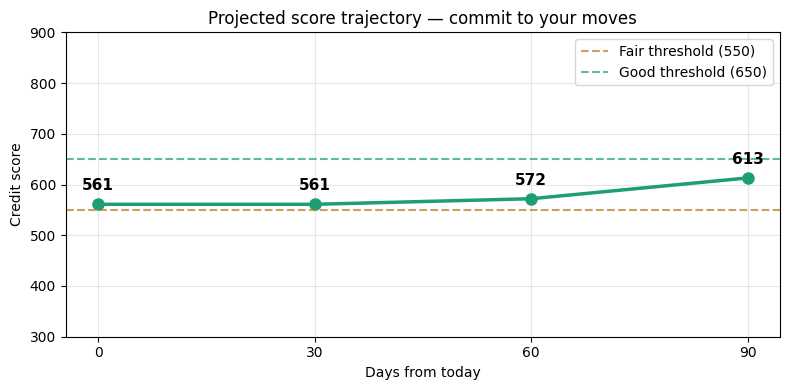

In [22]:
def project_trajectory(user: pd.DataFrame, model, days: list = [0, 30, 60, 90]) -> dict:
    """
    Project credit score over time assuming user takes all recommended moves.
    Applies moves gradually based on their timeline.
    """
    base_prob  = model.predict_proba(user)[0, 1]
    base_score = probability_to_score(base_prob)['score']
    moves = generate_moves(user, model, n_moves=5)

    trajectory = {}
    for day in days:
        modified = user.copy()
        for move in moves:
            if move['timeline_days'] <= day:
                modified[move['feature']] = move['new_val']

        prob  = model.predict_proba(modified)[0, 1]
        score = probability_to_score(prob)
        trajectory[day] = {
            'score': score['score'],
            'tier':  score['tier'],
            'moves_applied': sum(
                1 for m in moves if m['timeline_days'] <= day
            )
        }

    return trajectory

# ── Demo trajectory ───────────────────────────────────────────────────
if rejected_mask.sum() > 0:
    traj = project_trajectory(rejected_user, model_full)

    print('Score trajectory (if user commits to all moves):')
    print(f'{"Day":>6} | {"Score":>6} | {"Tier":>10} | {"Moves applied":>14}')
    print('-' * 46)
    for day, info in traj.items():
        print(f'{day:>6} | {info["score"]:>6} | {info["tier"]:>10} | {info["moves_applied"]:>14}')

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    days_list  = list(traj.keys())
    scores_list = [traj[d]['score'] for d in days_list]

    ax.plot(days_list, scores_list, 'o-', color='#1D9E75',
            linewidth=2.5, markersize=8)
    ax.axhline(550, color='#BA7517', linestyle='--', alpha=0.7, label='Fair threshold (550)')
    ax.axhline(650, color='#1D9E75', linestyle='--', alpha=0.7, label='Good threshold (650)')

    for day, score in zip(days_list, scores_list):
        ax.annotate(str(score), (day, score),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=11, fontweight='bold')

    ax.set_xlabel('Days from today')
    ax.set_ylabel('Credit score')
    ax.set_title('Projected score trajectory — commit to your moves')
    ax.legend()
    ax.set_ylim(300, 900)
    ax.set_xticks(days_list)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('./artifacts/score_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()

## Cell 17 — Fairness audit (AIF360)

Shows the lender (B2B buyer) that the model doesn't discriminate by gender or income group. This is the regulatory compliance feature that makes NBFCs willing to integrate.

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


CODE_GENDER not available for fairness audit in this split

Approval rate by income band:
income_band
Low        0.649
Mid-low    0.637
Mid-high   0.643
High       0.737

=== THIN-FILE vs BUREAU FAIRNESS CROSS-TAB ===
Approval rate by income band × bureau status:
group        Bureau users  Thin-file users  gap (Thin − Bureau)
income_band                                                    
Low                 0.656            0.611               -0.045
Mid-low             0.644            0.589               -0.055
Mid-high            0.647            0.605               -0.042
High                0.738            0.722               -0.017

Interpretation: Gap close to 0 means thin-file users are approved at the
same rate as equivalent bureau users in the same income band.
A large negative gap means the model still penalises thin-file users.


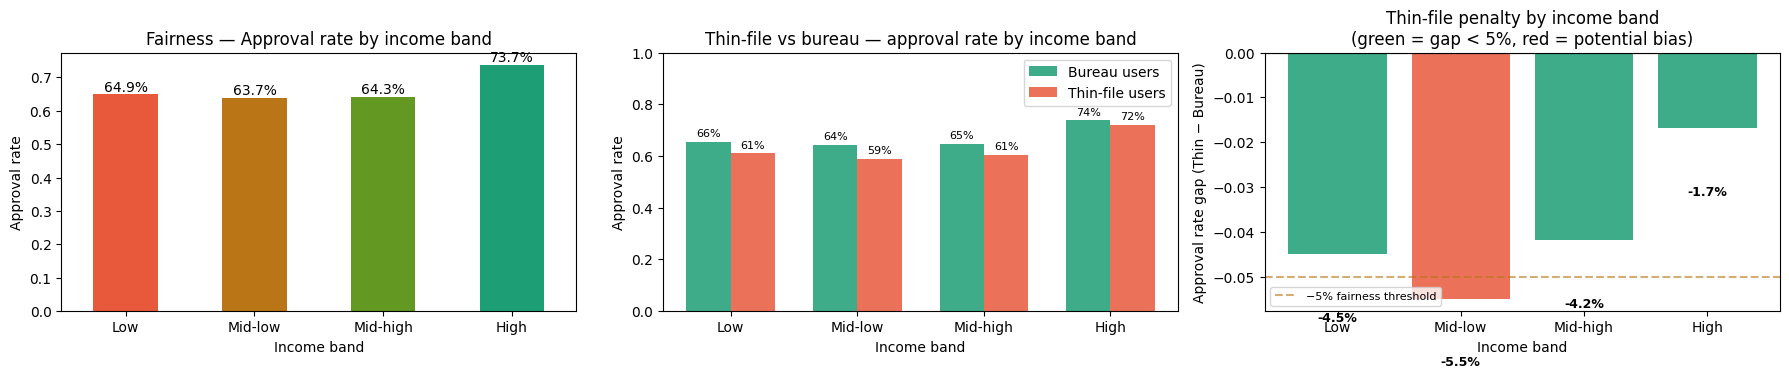

Saved: ./artifacts/fairness_income_bands.png
Saved: ./artifacts/fairness_thinfile_crosstab.csv


In [23]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

# ── Prepare AIF360 dataset ────────────────────────────────────────────
# Protected attribute: gender (0=Male, 1=Female after encoding)
audit_df = X_test.copy()
audit_df['TARGET'] = y_test.values
audit_df['PREDICTED'] = model_full.predict(X_test)

# Only run if CODE_GENDER is present and has both values
if 'CODE_GENDER' in audit_df.columns and audit_df['CODE_GENDER'].nunique() > 1:

    # AIF360 needs predicted dataset too
    aif_dataset_true = BinaryLabelDataset(
        df                = audit_df[['CODE_GENDER', 'TARGET']].rename(
                               columns={'TARGET': 'label'}),
        label_names       = ['label'],
        protected_attribute_names = ['CODE_GENDER'],
        favorable_label   = 0,   # 0 = repaid = good
        unfavorable_label = 1    # 1 = default = bad
    )

    aif_dataset_pred = BinaryLabelDataset(
        df                = audit_df[['CODE_GENDER', 'PREDICTED']].rename(
                               columns={'PREDICTED': 'label'}),
        label_names       = ['label'],
        protected_attribute_names = ['CODE_GENDER'],
        favorable_label   = 0,
        unfavorable_label = 1
    )

    # Gender code varies by encoding — find which value is more common
    gender_vals = sorted(audit_df['CODE_GENDER'].unique())
    privileged_groups   = [{'CODE_GENDER': gender_vals[0]}]
    unprivileged_groups = [{'CODE_GENDER': gender_vals[1]}]

    metric = ClassificationMetric(
        aif_dataset_true, aif_dataset_pred,
        unprivileged_groups = unprivileged_groups,
        privileged_groups   = privileged_groups
    )

    disparate_impact     = metric.disparate_impact()
    stat_parity_diff     = metric.statistical_parity_difference()
    equal_opport_diff    = metric.equal_opportunity_difference()

    print('=' * 50)
    print('FAIRNESS AUDIT — Gender')
    print('=' * 50)
    print(f'Disparate Impact:              {disparate_impact:.4f}')
    print(f'  (> 0.8 is considered fair)')
    print(f'Statistical Parity Difference: {stat_parity_diff:.4f}')
    print(f'  (close to 0 is fair)')
    print(f'Equal Opportunity Difference:  {equal_opport_diff:.4f}')
    print(f'  (close to 0 is fair)')
    print()

    if disparate_impact >= 0.8:
        print('RESULT: Model passes disparate impact test (DI >= 0.8)')
    else:
        print('RESULT: Model shows potential gender bias — review features')

    # Save fairness metrics for API
    fairness_metrics = {
        'disparate_impact':          round(disparate_impact, 4),
        'statistical_parity_diff':   round(stat_parity_diff, 4),
        'equal_opportunity_diff':    round(equal_opport_diff, 4),
        'fair':                      bool(disparate_impact >= 0.8)
    }
    with open('./artifacts/fairness_metrics.json', 'w') as f:
        json.dump(fairness_metrics, f, indent=2)
    print('\nFairness metrics saved to ./artifacts/fairness_metrics.json')

else:
    print('CODE_GENDER not available for fairness audit in this split')

# ── Approval rate breakdown by income band ────────────────────────────
income_bands = pd.qcut(X_test['AMT_INCOME_TOTAL'], q=4,
                        labels=['Low', 'Mid-low', 'Mid-high', 'High'])
approval_by_income = pd.DataFrame({
    'income_band':   income_bands,
    'approved':      (model_full.predict(X_test) == 0)
}).groupby('income_band', observed=True)['approved'].mean()

print('\nApproval rate by income band:')
print(approval_by_income.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: income band approval rates (original)
approval_by_income.plot(kind='bar', ax=axes[0],
                        color=['#E8593C', '#BA7517', '#639922', '#1D9E75'])
axes[0].set_ylabel('Approval rate')
axes[0].set_xlabel('Income band')
axes[0].set_title('Fairness — Approval rate by income band')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(approval_by_income):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# ── THIN-FILE FAIRNESS CROSS-TAB ──────────────────────────────────────
# This is the most important fairness check for this problem statement.
# Question: Within the same income band, does the model approve thin-file
# users at a meaningfully lower rate than bureau users?
# If yes → the model is replicating bureau bias. If no → we've solved it.
audit_df_full = X_test.copy()
audit_df_full['income_band']  = income_bands.values
audit_df_full['approved']     = (model_full.predict(X_test) == 0).astype(int)
audit_df_full['is_thin_file'] = thin_test.values

cross_tab = audit_df_full.groupby(
    ['income_band', 'is_thin_file'], observed=True
)['approved'].agg(['mean', 'count']).reset_index()
cross_tab.columns = ['income_band', 'is_thin_file', 'approval_rate', 'n_users']
cross_tab['group'] = cross_tab['is_thin_file'].map({0: 'Bureau users', 1: 'Thin-file users'})

print('\n=== THIN-FILE vs BUREAU FAIRNESS CROSS-TAB ===')
print('Approval rate by income band × bureau status:')
pivot = cross_tab.pivot_table(
    index='income_band', columns='group',
    values='approval_rate', aggfunc='first'
)
pivot['gap (Thin − Bureau)'] = pivot['Thin-file users'] - pivot['Bureau users']
print(pivot.round(3).to_string())
print()
print('Interpretation: Gap close to 0 means thin-file users are approved at the')
print('same rate as equivalent bureau users in the same income band.')
print('A large negative gap means the model still penalises thin-file users.')

# Plot 2: cross-tab bar chart
bands = ['Low', 'Mid-low', 'Mid-high', 'High']
bureau_rates = []
thin_rates   = []
for band in bands:
    subset = cross_tab[cross_tab['income_band'] == band]
    bureau_row = subset[subset['group'] == 'Bureau users']
    thin_row   = subset[subset['group'] == 'Thin-file users']
    bureau_rates.append(bureau_row['approval_rate'].values[0] if len(bureau_row) > 0 else 0)
    thin_rates.append(thin_row['approval_rate'].values[0]     if len(thin_row)   > 0 else 0)

x    = np.arange(len(bands))
width = 0.35
axes[1].bar(x - width/2, bureau_rates, width, label='Bureau users',     color='#1D9E75', alpha=0.85)
axes[1].bar(x + width/2, thin_rates,   width, label='Thin-file users',  color='#E8593C', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bands)
axes[1].set_ylabel('Approval rate')
axes[1].set_xlabel('Income band')
axes[1].set_title('Thin-file vs bureau — approval rate by income band')
axes[1].legend()
axes[1].set_ylim(0, 1)
for i, (b, t) in enumerate(zip(bureau_rates, thin_rates)):
    axes[1].text(i - width/2, b + 0.02, f'{b:.0%}', ha='center', fontsize=8)
    axes[1].text(i + width/2, t + 0.02, f'{t:.0%}', ha='center', fontsize=8)

# Plot 3: approval rate gap (thin − bureau)
gaps = [t - b for t, b in zip(thin_rates, bureau_rates)]
colors = ['#1D9E75' if g >= -0.05 else '#E8593C' for g in gaps]
axes[2].bar(bands, gaps, color=colors, alpha=0.85)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].axhline(-0.05, color='#BA7517', linestyle='--', alpha=0.6,
                label='−5% fairness threshold')
axes[2].set_ylabel('Approval rate gap (Thin − Bureau)')
axes[2].set_xlabel('Income band')
axes[2].set_title('Thin-file penalty by income band\n(green = gap < 5%, red = potential bias)')
axes[2].legend(fontsize=8)
for i, g in enumerate(gaps):
    axes[2].text(i, g + (0.005 if g >= 0 else -0.015),
                 f'{g:+.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./artifacts/fairness_income_bands.png', dpi=150, bbox_inches='tight')
plt.show()

# Save cross-tab to artifacts for API
cross_tab.to_csv('./artifacts/fairness_thinfile_crosstab.csv', index=False)
print('Saved: ./artifacts/fairness_income_bands.png')
print('Saved: ./artifacts/fairness_thinfile_crosstab.csv')

## Cell 18 — Inference function (powers the FastAPI)

This is the single function your API calls. Input: raw user profile dict. Output: complete scoring response.

In [24]:
def score_user_complete(user_input: dict) -> dict:
    """
    End-to-end scoring pipeline for a single user.
    Accepts raw form inputs, returns complete scoring response.

    Input dict keys (all collectable from a form):
      income, employment_type, employment_years, age, gender,
      education, family_status, n_children, n_family,
      owns_car, owns_realty, housing_type,
      loan_amount, monthly_emi, occupation, organization
    """
    # ── 1. Map form inputs to model features ──────────────────────────
    income           = float(user_input.get('income', 150000))
    employment_years = float(user_input.get('employment_years', 2))
    age              = float(user_input.get('age', 30))
    n_children       = int(user_input.get('n_children', 0))
    n_family         = int(user_input.get('n_family', 2))
    owns_car         = int(user_input.get('owns_car', 0))
    owns_realty      = int(user_input.get('owns_realty', 0))
    loan_amount      = float(user_input.get('loan_amount', 200000))
    monthly_emi      = float(user_input.get('monthly_emi', 10000))

    # ── 2. Build feature row matching training schema ──────────────────
    # Load encoders
    le_dict = joblib.load('./artifacts/label_encoders.pkl')
    imp = joblib.load('./artifacts/imputer.pkl')

    def safe_encode(encoder, value, default=0):
        try:
            return encoder.transform([str(value)])[0]
        except:
            return default

    feature_row = {
        # NOTE: CODE_GENDER and AGE_YEARS deliberately excluded — protected attributes.
        # AGE_YEARS still feeds into ratio features below (EMPLOYMENT_AGE_RATIO).
        'CNT_CHILDREN':              n_children,
        'CNT_FAM_MEMBERS':           n_family,
        'NAME_EDUCATION_TYPE':       safe_encode(le_dict['NAME_EDUCATION_TYPE'],
                                         user_input.get('education', 'Secondary')),
        'NAME_FAMILY_STATUS':        safe_encode(le_dict['NAME_FAMILY_STATUS'],
                                         user_input.get('family_status', 'Single')),
        'NAME_INCOME_TYPE':          safe_encode(le_dict['NAME_INCOME_TYPE'],
                                         user_input.get('employment_type', 'Working')),
        'OCCUPATION_TYPE':           safe_encode(le_dict['OCCUPATION_TYPE'],
                                         user_input.get('occupation', 'Unknown')),
        'ORGANIZATION_TYPE':         safe_encode(le_dict['ORGANIZATION_TYPE'],
                                         user_input.get('organization', 'Unknown')),
        'FLAG_OWN_CAR':              owns_car,
        'FLAG_OWN_REALTY':           owns_realty,
        'NAME_HOUSING_TYPE':         safe_encode(le_dict['NAME_HOUSING_TYPE'],
                                         user_input.get('housing_type', 'Rented')),
        'AMT_INCOME_TOTAL':          income,
        'AMT_CREDIT':                loan_amount,
        'AMT_ANNUITY':               monthly_emi,
        'AMT_GOODS_PRICE':           loan_amount * 0.9,
        'NAME_CONTRACT_TYPE':        safe_encode(le_dict['NAME_CONTRACT_TYPE'], 'Cash loans'),
        'REGION_POPULATION_RELATIVE': 0.035,  # median value
        'REGION_RATING_CLIENT':       2,
        'REGION_RATING_CLIENT_W_CITY': 2,
        'FLAG_DOCUMENT_3':            int(user_input.get('has_doc_3', 1)),
        'FLAG_DOCUMENT_5':            0,
        'FLAG_DOCUMENT_6':            0,
        'FLAG_DOCUMENT_8':            0,
        'FLAG_MOBIL':                 1,
        'FLAG_EMAIL':                 int(user_input.get('has_email', 0)),
        'FLAG_PHONE':                 int(user_input.get('has_phone', 1)),
        'FLAG_WORK_PHONE':            int(user_input.get('has_work_phone', 0)),
        'AGE_YEARS':                  age,
        'EMPLOYMENT_YEARS':           employment_years,
        # Engineered
        'CREDIT_INCOME_RATIO':        loan_amount / (income + 1),
        'ANNUITY_INCOME_RATIO':       monthly_emi / ((income / 12) + 1),
        'EMPLOYMENT_AGE_RATIO':       employment_years / (age + 1),
        'INCOME_PER_PERSON':          income / (n_family + 1),
        'CREDIT_TERM':                monthly_emi / (loan_amount + 1),
        'DOWN_PAYMENT_RATIO':         (loan_amount - loan_amount * 0.9) / (loan_amount * 0.9 + 1),
        'ASSET_SCORE':                owns_car + owns_realty,
        'CHILDREN_INCOME_RATIO':      n_children / ((income / 12) + 1),
    }

    # ── 3. Align with training feature order ───────────────────────────
    with open('./artifacts/feature_cols.json') as f:
        feature_cols = json.load(f)

    user_df = pd.DataFrame([feature_row])
    for col in feature_cols:
        if col not in user_df.columns:
            user_df[col] = 0
    user_df = user_df[feature_cols]

    # ── 4. Impute ──────────────────────────────────────────────────────
    user_imputed = pd.DataFrame(
        imp.transform(user_df),
        columns=feature_cols
    )

    # ── 5. Score ───────────────────────────────────────────────────────
    model = joblib.load('./artifacts/model_full.pkl')
    prob  = model.predict_proba(user_imputed)[0, 1]
    score_result = probability_to_score(prob)

    # ── 6. SHAP explanation ────────────────────────────────────────────
    expl = joblib.load('./artifacts/shap_explainer.pkl')
    explanation = explain_user(user_imputed.iloc[0], expl)

    # ── 7. Moves ───────────────────────────────────────────────────────
    moves = generate_moves(user_imputed, model, n_moves=3)

    # ── 8. Trajectory ──────────────────────────────────────────────────
    trajectory = project_trajectory(user_imputed, model)

    return {
        'score':              score_result['score'],
        'tier':               score_result['tier'],
        'default_probability': score_result['default_probability'],
        'approval_probability': score_result['approval_probability'],
        'loan_eligible':       score_result['loan_eligible'],
        'top_factors_hurting': explanation['hurting_score'][:3],
        'top_factors_helping': explanation['helping_score'][:3],
        'moves':               moves,
        'trajectory':          trajectory,
    }

# ── Test the complete pipeline ────────────────────────────────────────
test_user = {
    'income':           180000,    # ₹15,000/month
    'employment_type':  'Working',
    'employment_years': 1.5,
    'age':              26,
    'gender':           'M',
    'education':        'Secondary / secondary special',
    'family_status':    'Single / not married',
    'n_children':       0,
    'n_family':         1,
    'owns_car':         0,
    'owns_realty':      0,
    'housing_type':     'Rented apartment',
    'loan_amount':      200000,    # ₹2 lakh
    'monthly_emi':      8000,
    'occupation':       'Laborers',
    'organization':     'Business Entity Type 3',
    'has_email':        0,
    'has_phone':        1,
}

result = score_user_complete(test_user)

print('=' * 60)
print(f'CREDIT SCORE:  {result["score"]}  ({result["tier"]})')
print(f'LOAN ELIGIBLE: {result["loan_eligible"]}')
print(f'DEFAULT PROB:  {result["default_probability"]:.1%}')
print('=' * 60)
print('\nTop factors hurting your score:')
for f in result['top_factors_hurting']:
    print(f'  - {f["feature"]}: SHAP +{f["shap"]:.4f}')
print('\nRecommended moves:')
for m in result['moves']:
    print(f'  + {m["advice"]}  →  +{m["score_delta"]} pts  ({m["effort"]} effort)')
print('\nScore trajectory:')
for day, info in result['trajectory'].items():
    print(f'  Day {day:>3}: {info["score"]}  ({info["tier"]})')

CREDIT SCORE:  616  (Fair)
LOAN ELIGIBLE: True
DEFAULT PROB:  44.4%

Top factors hurting your score:
  - EMPLOYMENT_YEARS: SHAP +0.2695
  - NAME_HOUSING_TYPE: SHAP +0.0955
  - OCCUPATION_TYPE: SHAP +0.0890

Recommended moves:
  + Maintain your current employment for {delta:.0f} more months  →  +5 pts  (low effort)

Score trajectory:
  Day   0: 616  (Fair)
  Day  30: 616  (Fair)
  Day  60: 616  (Fair)
  Day  90: 621  (Fair)


## Cell 19 — Demo personas

Three pre-built personas for the live demo. Each tells a different story.

In [25]:
DEMO_PERSONAS = {
    'ravi': {
        'name':             'Ravi — Swiggy delivery partner',
        'income':           216000,   # ₹18k/month
        'employment_type':  'Working',
        'employment_years': 0.8,      # less than a year
        'age':              24,
        'gender':           'M',
        'education':        'Secondary / secondary special',
        'family_status':    'Single / not married',
        'n_children':       0,
        'n_family':         1,
        'owns_car':         0,
        'owns_realty':      0,
        'housing_type':     'Rented apartment',
        'loan_amount':      150000,
        'monthly_emi':      7000,
        'occupation':       'Drivers',
        'organization':     'Transport: type 3',
        'has_email':        0,
        'has_phone':        1,
        'story':            'Gig worker, no CIBIL score, needs loan for bike repair'
    },
    'priya': {
        'name':             'Priya — homemaker, secondary income',
        'income':           120000,   # ₹10k/month from tuitions
        'employment_type':  'Commercial associate',
        'employment_years': 3,
        'age':              34,
        'gender':           'F',
        'education':        'Higher education',
        'family_status':    'Married',
        'n_children':       2,
        'n_family':         4,
        'owns_car':         0,
        'owns_realty':      1,       # husband owns property
        'housing_type':     'House / apartment',
        'loan_amount':      100000,
        'monthly_emi':      5000,
        'occupation':       'Unknown',
        'organization':     'Unknown',
        'has_email':        1,
        'has_phone':        1,
        'story':            'Homemaker with property collateral but no formal employment'
    },
    'deepa': {
        'name':             'Deepa — freelance graphic designer',
        'income':           360000,   # ₹30k/month variable
        'employment_type':  'Commercial associate',
        'employment_years': 2.5,
        'age':              28,
        'gender':           'F',
        'education':        'Higher education',
        'family_status':    'Single / not married',
        'n_children':       0,
        'n_family':         1,
        'owns_car':         0,
        'owns_realty':      0,
        'housing_type':     'Rented apartment',
        'loan_amount':      300000,
        'monthly_emi':      12000,
        'occupation':       'Unknown',
        'organization':     'Unknown',
        'has_email':        1,
        'has_phone':        1,
        'story':            'Freelancer with decent income but irregular cash flows'
    }
}

print('Demo persona scores:')
print('=' * 60)

persona_results = {}
for key, persona in DEMO_PERSONAS.items():
    result = score_user_complete(persona)
    persona_results[key] = result

    print(f'\n{persona["name"]}')
    print(f'Story: {persona["story"]}')
    print(f'Score: {result["score"]}  ({result["tier"]})')
    print(f'Eligible: {result["loan_eligible"]} | Default prob: {result["default_probability"]:.1%}')
    print(f'Top move: {result["moves"][0]["advice"]} → +{result["moves"][0]["score_delta"]} pts')
    print('-' * 40)

# Save persona results for frontend demo
with open('./artifacts/demo_personas.json', 'w') as f:
    json.dump(persona_results, f, indent=2, default=str)
print('\nSaved persona results to ./artifacts/demo_personas.json')

Demo persona scores:

Ravi — Swiggy delivery partner
Story: Gig worker, no CIBIL score, needs loan for bike repair
Score: 551  (Fair)
Eligible: True | Default prob: 65.7%
Top move: Maintain your current employment for {delta:.0f} more months → +1 pts
----------------------------------------

Priya — homemaker, secondary income
Story: Homemaker with property collateral but no formal employment
Score: 656  (Good)
Eligible: True | Default prob: 32.0%
Top move: Maintain your current employment for {delta:.0f} more months → +8 pts
----------------------------------------

Deepa — freelance graphic designer
Story: Freelancer with decent income but irregular cash flows
Score: 642  (Fair)
Eligible: True | Default prob: 36.1%
Top move: Maintain your current employment for {delta:.0f} more months → +8 pts
----------------------------------------

Saved persona results to ./artifacts/demo_personas.json


## Cell 20 — Export everything for FastAPI

In [26]:
import os

artifacts = [
    './artifacts/model_full.pkl',
    './artifacts/model_thin.pkl',
    './artifacts/shap_explainer.pkl',
    './artifacts/label_encoders.pkl',
    './artifacts/imputer.pkl',
    './artifacts/feature_cols.json',
    './artifacts/fairness_metrics.json',
    './artifacts/fairness_thinfile_crosstab.csv',
    './artifacts/demo_personas.json',
    './artifacts/shap_importance.csv',
]

print('Artifact export summary:')
print('=' * 50)
all_good = True
for path in artifacts:
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1024:.1f} KB' if exists else 'MISSING'
    status = 'OK' if exists else 'MISSING'
    print(f'  {status:>7}  {path:45} {size}')
    if not exists:
        all_good = False

print()
if all_good:
    print('All artifacts ready. Copy ./artifacts/ to your FastAPI project.')
    print()
    print('FastAPI usage:')
    print('  POST /v1/score          → score_user_complete(user_input)')
    print('  POST /v1/counterfactual → generate_moves(user_df, model)')
    print('  GET  /v1/fairness       → load fairness_metrics.json')
    print('  GET  /v1/passport/:id   → load demo_personas.json[id]')
else:
    print('Some artifacts missing — re-run cells above.')

Artifact export summary:
       OK  ./artifacts/model_full.pkl                    897.7 KB
       OK  ./artifacts/model_thin.pkl                    240.2 KB
       OK  ./artifacts/shap_explainer.pkl                2715.1 KB
       OK  ./artifacts/label_encoders.pkl                3.4 KB
       OK  ./artifacts/imputer.pkl                       1.6 KB
       OK  ./artifacts/feature_cols.json                 0.7 KB
       OK  ./artifacts/fairness_metrics.json             0.1 KB
       OK  ./artifacts/fairness_thinfile_crosstab.csv    0.4 KB
       OK  ./artifacts/demo_personas.json                6.4 KB
       OK  ./artifacts/shap_importance.csv               1.6 KB

All artifacts ready. Copy ./artifacts/ to your FastAPI project.

FastAPI usage:
  POST /v1/score          → score_user_complete(user_input)
  POST /v1/counterfactual → generate_moves(user_df, model)
  GET  /v1/fairness       → load fairness_metrics.json
  GET  /v1/passport/:id   → load demo_personas.json[id]


=== BASIC METRICS ===
Accuracy : 0.7070711997788726
Precision: 0.14273200109499043
Recall   : 0.5250755287009063
F1 Score : 0.22445114076625053
ROC-AUC  : 0.6773898238534647

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     56538
           1       0.14      0.53      0.22      4965

    accuracy                           0.71     61503
   macro avg       0.54      0.62      0.52     61503
weighted avg       0.88      0.71      0.77     61503


=== CONFUSION MATRIX ===
[[40880 15658]
 [ 2358  2607]]


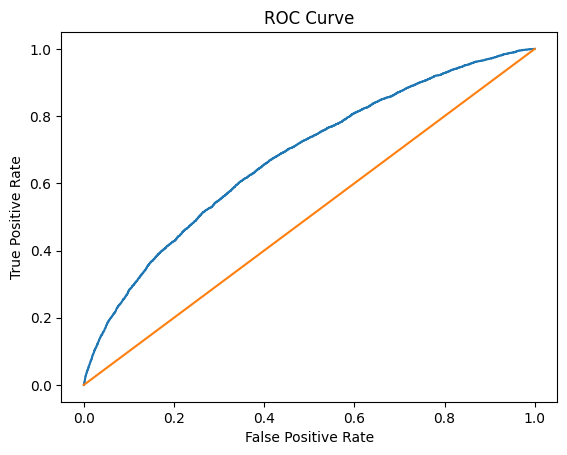

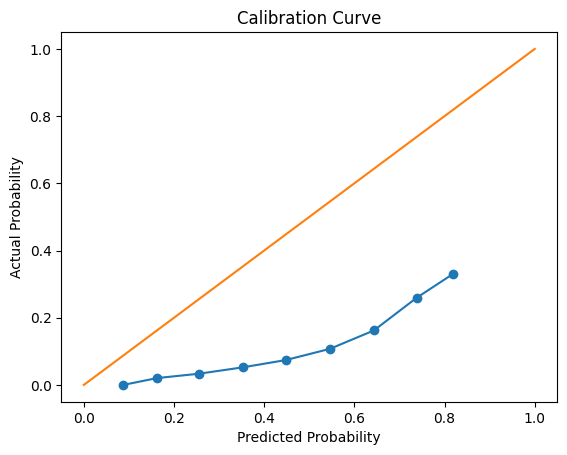


=== THRESHOLD TUNING ===

Threshold: 0.2
Precision: 0.08368414773405143
Recall   : 0.9889224572004028

Threshold: 0.3
Precision: 0.0920950581684399
Recall   : 0.9327291037260825

Threshold: 0.4
Precision: 0.11050286812450863
Recall   : 0.7643504531722054

Threshold: 0.5
Precision: 0.14273200109499043
Recall   : 0.5250755287009063

Threshold: 0.6
Precision: 0.19134840218238502
Recall   : 0.29667673716012083


In [28]:
# ── MODEL TESTING (NO RETRAINING) ─────────────────────────────────────

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
import numpy as np

# Choose which model to evaluate
model = model_thin   # or model_thin

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ── Basic Metrics ─────────────────────────────────────────────────────
print("=== BASIC METRICS ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))


# ── ROC CURVE ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# ── CALIBRATION CURVE ────────────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1])
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.show()


# ── THRESHOLD TESTING (VERY IMPORTANT) ────────────────────────────────
print("\n=== THRESHOLD TUNING ===")
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall   :", recall_score(y_test, y_pred_t))